# 3. Visual Exploratory Data Analysis

Figures describing delays and their association with weather, on the study dataset built by the pipeline (training period 2018–2021). Weather is the realized weather at the scheduled departure/arrival hours; this descriptive use is distinct from the deployable features used for prediction. Figures are written to `EDA/figures/`.

## 3.1 Setup and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from pathlib import Path

# Okabe-Ito palette (colorblind-safe, scientific standard)
OKABE_ITO = ['#000000', '#E69F00', '#56B4E9', '#009E73',
             '#F0E442', '#0072B2', '#D55E00', '#CC79A7']

# Semantic colors (for weather categories)
COLOR_GOOD = '#009E73'   # bluish green (VFR / no rain)
COLOR_MID = '#F0E442'    # yellow (MVFR)
COLOR_BAD = '#E69F00'    # orange (IFR)
COLOR_WORST = '#D55E00'  # vermillion (LIFR / thunderstorm)
COLOR_ORG = '#0072B2'    # blue (Origin)
COLOR_DST = '#CC79A7'    # purple (Destination)

# Matplotlib rcParams for publication
mpl.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['DejaVu Sans', 'Arial'],
    'font.size': 10,
    'axes.titlesize': 11,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linewidth': 0.5,
})


def save_fig(fig, name):
    '''Save figure as both PDF (paper) and PNG (preview).'''
    fig.savefig(FIG_DIR / f'{name}.pdf', bbox_inches='tight', dpi=300)
    fig.savefig(FIG_DIR / f'{name}.png', bbox_inches='tight', dpi=150)
    print(f'saved {name}.pdf/.png')

In [2]:
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'README.md').exists())  # project root
DATA = ROOT / 'data' / 'processed'          # outputs of 02_weather_processing and 03_flights_information_settings
TRAIN_END = '2022-01-01'

FLIGHT_COLS = ['row_id', 'FlightDate', 'Airline', 'Origin', 'Dest', 'OriginState', 'DestState',
               'CRSDepHour', 'Month', 'DayOfWeek', 'Distance', 'CRSElapsedTime',
               'ArrDelay', 'ArrDelayMinutes', 'ArrDel15']
WX = ['temp_f', 'dewpt_f', 'humidity', 'wind_mph', 'gust_mph', 'visibility_mi', 'precip_in', 'pressure',
      'ceiling_ft', 'has_rain', 'has_snow', 'has_fog', 'has_mist', 'has_thunder', 'has_freezing',
      'is_heavy', 'has_gust', 'flight_cat_ord']
WX_COLS = ['row_id'] + [f'{p}_{c}' for p in ('org', 'dst') for c in WX]

fl = pd.read_parquet(DATA / 'flights_clean.parquet', columns=FLIGHT_COLS)
wx = pd.read_parquet(DATA / 'wx_oracle.parquet', columns=WX_COLS)   # realized weather at scheduled times (descriptive use)
assert (fl['row_id'].values == wx['row_id'].values).all()
df_all = pd.concat([fl, wx.drop(columns='row_id')], axis=1)
del fl, wx
df_all['FlightDate'] = pd.to_datetime(df_all['FlightDate'])
FLIGHT_CAT = {0: 'VFR', 1: 'MVFR', 2: 'IFR', 3: 'LIFR'}            # FAA category (ceiling and visibility)
for p in ('org', 'dst'):
    df_all[f'{p}_ceiling_cat'] = df_all[f'{p}_flight_cat_ord'].map(FLIGHT_CAT)

df = df_all[df_all['FlightDate'] < TRAIN_END].reset_index(drop=True)   # training period
print(f'All flights: {len(df_all):,} | training period (2018-2021): {len(df):,}')

FIG_DIR = ROOT / 'EDA' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

All flights: 9,981,331 | training period (2018-2021): 8,550,324


## 3.2 Delay distribution
Histogram of `ArrDelayMinutes` (clipped at 180 min) and its cumulative distribution.

saved fig1_delay_distribution.pdf/.png


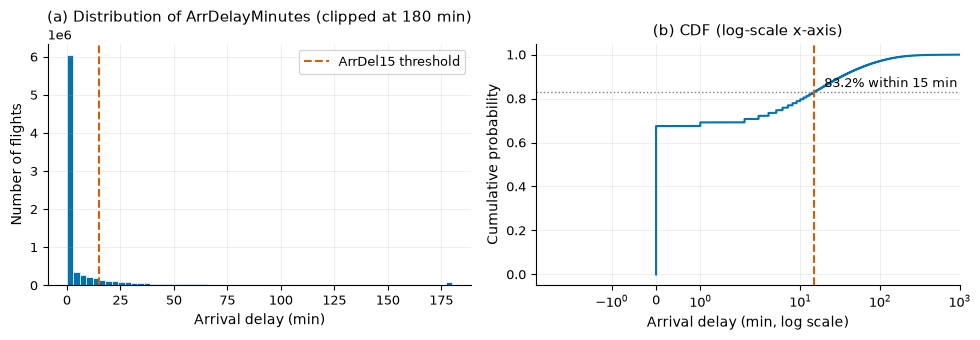

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

y = df['ArrDelayMinutes']

# Panel A: Histogram (clip at 180 min for readability)
axes[0].hist(y.clip(upper=180), bins=60, color=COLOR_ORG, edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Arrival delay (min)')
axes[0].set_ylabel('Number of flights')
axes[0].set_title('(a) Distribution of ArrDelayMinutes (clipped at 180 min)')
axes[0].axvline(15, color=COLOR_WORST, linestyle='--', linewidth=1.5, label='ArrDel15 threshold')
axes[0].legend(loc='upper right')

# Panel B: CDF with log-scale
y_sorted = np.sort(y.values)
cdf = np.arange(1, len(y_sorted)+1) / len(y_sorted)
axes[1].plot(y_sorted, cdf, color=COLOR_ORG, linewidth=1.5)
axes[1].set_xlabel('Arrival delay (min, log scale)')
axes[1].set_ylabel('Cumulative probability')
axes[1].set_title('(b) CDF (log-scale x-axis)')
axes[1].set_xscale('symlog')
axes[1].set_xlim(-5, 1000)
axes[1].axvline(15, color=COLOR_WORST, linestyle='--', linewidth=1.5)
axes[1].axhline(y.le(15).mean(), color='gray', linestyle=':', linewidth=1)
axes[1].text(20, y.le(15).mean()+0.02, f'{y.le(15).mean():.1%} within 15 min', fontsize=9)

plt.tight_layout()
save_fig(fig, 'fig1_delay_distribution')
plt.show()

## 3.3 Delay rate by departure hour and weekday

saved fig2_temporal_heatmap.pdf/.png


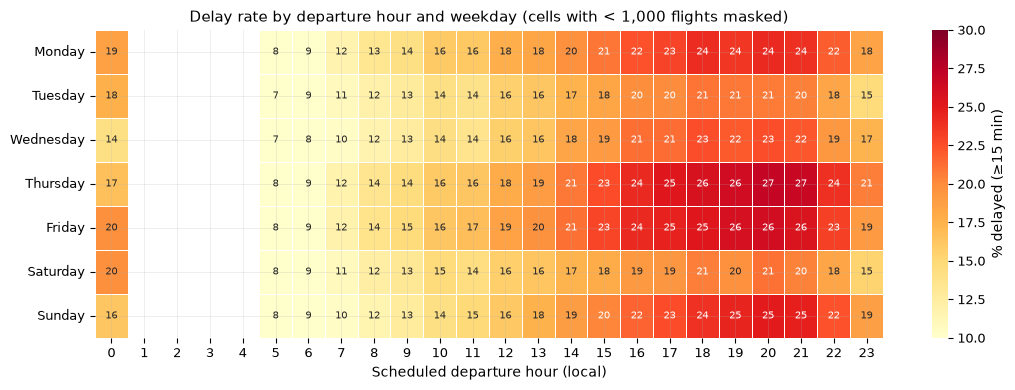

In [4]:
df['DayOfWeek_name'] = df['FlightDate'].dt.day_name()
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

pivot_rate = df.pivot_table(values='ArrDel15', index='DayOfWeek_name',
                            columns='CRSDepHour', aggfunc='mean')

pivot_n = df.pivot_table(values='ArrDel15', index='DayOfWeek_name',
                         columns='CRSDepHour', aggfunc='count')
pivot_rate = pivot_rate.mask(pivot_n < 1000)  # mask cells with < 1,000 flights
pivot_rate = pivot_rate.reindex(day_order)

fig, ax = plt.subplots(figsize=(11, 4))
sns.heatmap(pivot_rate * 100, cmap='YlOrRd', ax=ax,
            vmin=10, vmax=30,
            cbar_kws={'label': '% delayed (≥15 min)'},
            linewidths=0.5, linecolor='white',
            annot=True, fmt='.0f',
            annot_kws={'fontsize': 7})
ax.set_xlabel('Scheduled departure hour (local)')
ax.set_ylabel('')
ax.set_title('Delay rate by departure hour and weekday (cells with < 1,000 flights masked)')
plt.tight_layout()
save_fig(fig, 'fig2_temporal_heatmap')
plt.show()

## 3.4 Weather signature by state
Share of departures with each weather condition at the origin.

saved fig3_state_signatures.pdf/.png


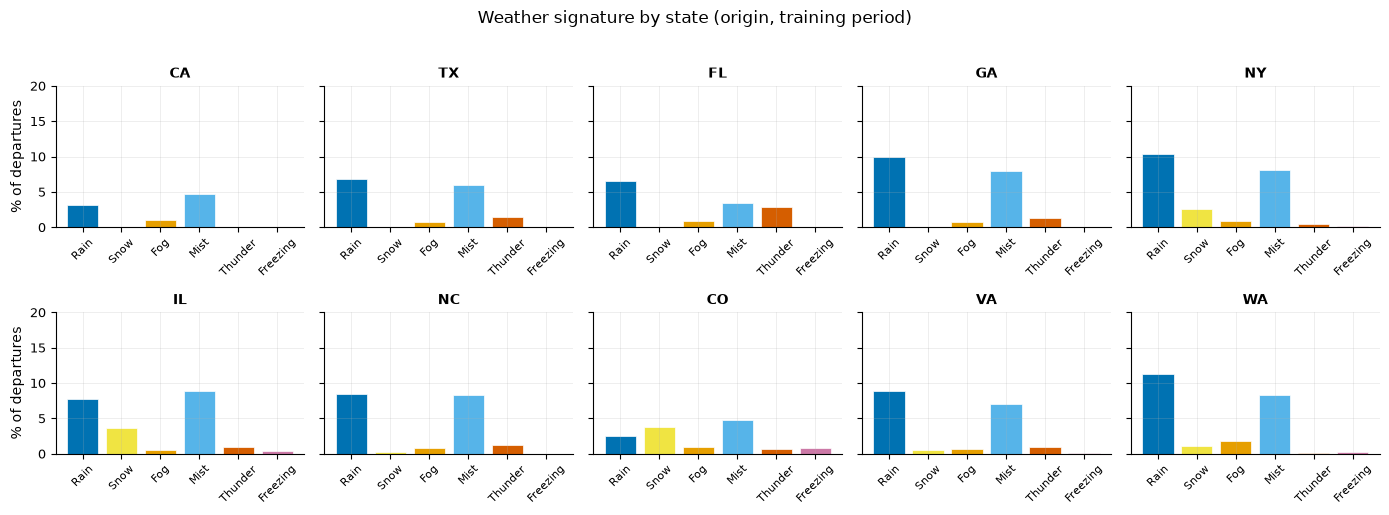

In [5]:
flags = ['has_rain', 'has_snow', 'has_fog', 'has_mist', 'has_thunder', 'has_freezing']
flag_labels = ['Rain', 'Snow', 'Fog', 'Mist', 'Thunder', 'Freezing']

states = df.groupby('OriginState').size().sort_values(ascending=False).index.tolist()

fig, axes = plt.subplots(2, 5, figsize=(14, 5), sharey=True)
axes = axes.flatten()

for i, state in enumerate(states):
    subset = df[df['OriginState'] == state]
    freqs = [subset[f'org_{f}'].mean() * 100 for f in flags]
    ax = axes[i]
    bars = ax.bar(flag_labels, freqs, color=[COLOR_ORG, COLOR_MID, COLOR_BAD, '#56B4E9', COLOR_WORST, '#CC79A7'],
                   edgecolor='white', linewidth=0.5)
    ax.set_title(f'{state}', fontsize=10, fontweight='bold')
    ax.set_ylabel('% of departures' if i % 5 == 0 else '')
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.set_ylim(0, max(20, max(freqs) * 1.1))

fig.suptitle('Weather signature by state (origin, training period)', fontsize=12, y=1.02)
plt.tight_layout()
save_fig(fig, 'fig3_state_signatures')
plt.show()

## 3.5 Continuous weather variables and delay
Mean delay per quantile bin of visibility, wind speed and (non-zero) precipitation at the origin.

saved fig4_weather_delay.pdf/.png


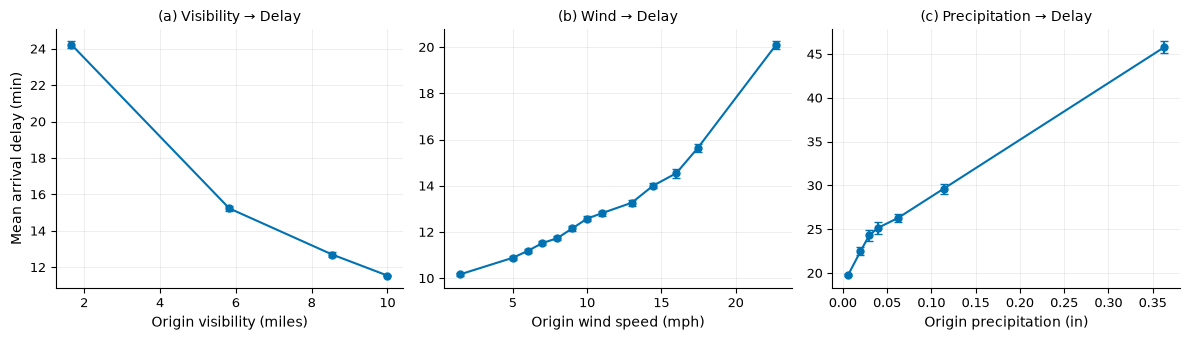

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))

def bin_plot(ax, x, y, xlabel, title, color, n_bins=20):
    '''Bin x into quantile bins and plot the mean of y per bin (95% CI).'''
    df_tmp = pd.DataFrame({'x': x, 'y': y}).dropna()
    df_tmp['bin'] = pd.qcut(df_tmp['x'], n_bins, duplicates='drop')
    grouped = df_tmp.groupby('bin').agg(x_mid=('x','mean'), y_mean=('y','mean'), y_sem=('y','sem'))
    ax.errorbar(grouped['x_mid'], grouped['y_mean'], yerr=grouped['y_sem']*1.96,
                fmt='o-', color=color, capsize=3, markersize=5, linewidth=1.5)
    ax.set_xlabel(xlabel)
    ax.set_title(title, fontsize=10)

# Panel A: Visibility (miles) — lower = worse
bin_plot(axes[0], df['org_visibility_mi'].clip(upper=10), df['ArrDelayMinutes'],
         'Origin visibility (miles)', '(a) Visibility → Delay', COLOR_ORG)
axes[0].set_ylabel('Mean arrival delay (min)')

# Panel B: Wind speed (mph) — higher = worse
bin_plot(axes[1], df['org_wind_mph'], df['ArrDelayMinutes'],
         'Origin wind speed (mph)', '(b) Wind → Delay', COLOR_ORG)

# Panel C: Precipitation (inches) — higher = worse
mask = df['org_precip_in'] > 0
bin_plot(axes[2], df.loc[mask, 'org_precip_in'], df.loc[mask, 'ArrDelayMinutes'],
         'Origin precipitation (in)', '(c) Precipitation → Delay', COLOR_ORG, n_bins=15)

plt.tight_layout()
save_fig(fig, 'fig4_weather_delay')
plt.show()

## 3.6 Correlation matrix

saved fig5_correlation.pdf/.png


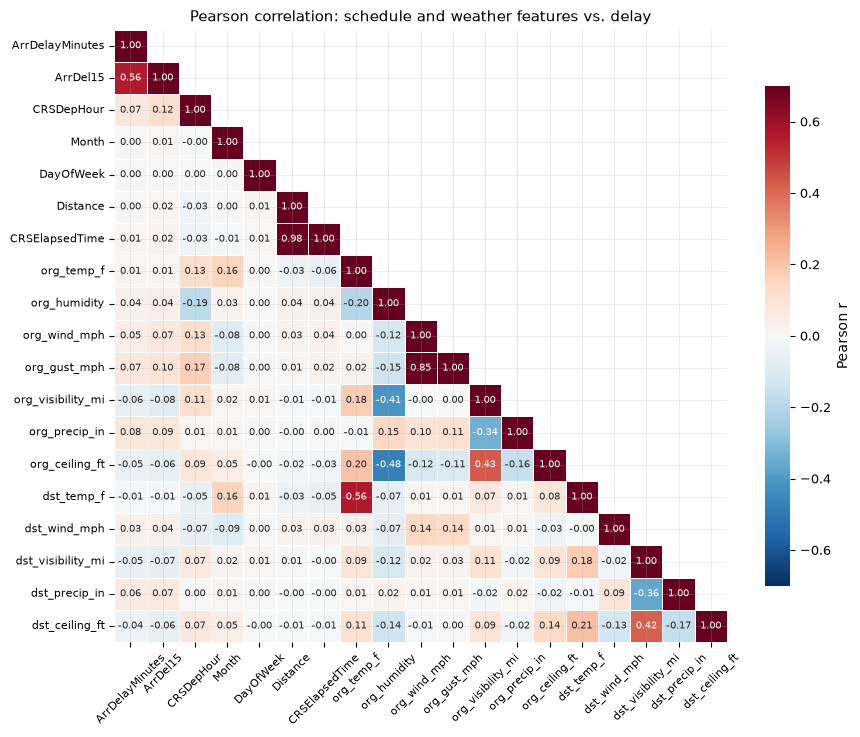

In [7]:
corr_cols = [
    'ArrDelayMinutes', 'ArrDel15',
    'CRSDepHour', 'Month', 'DayOfWeek', 'Distance', 'CRSElapsedTime',
    'org_temp_f', 'org_humidity', 'org_wind_mph', 'org_gust_mph',
    'org_visibility_mi', 'org_precip_in', 'org_ceiling_ft',
    'dst_temp_f', 'dst_wind_mph', 'dst_visibility_mi', 'dst_precip_in', 'dst_ceiling_ft',
]

corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(9, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0, vmin=-0.7, vmax=0.7,
            annot=True, fmt='.2f', square=True, linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Pearson r', 'shrink': 0.7}, ax=ax,
            annot_kws={'fontsize': 7})
ax.set_title('Pearson correlation: schedule and weather features vs. delay', fontsize=11)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', rotation=0, labelsize=8)

plt.tight_layout()
save_fig(fig, 'fig5_correlation')
plt.show()

## 3.7 Delay rate by weather condition

saved fig6_weather_flags.pdf/.png


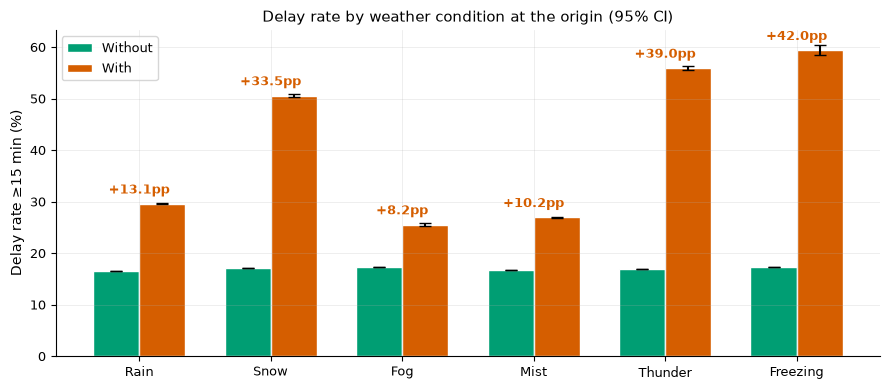

In [8]:
flags = ['org_has_rain', 'org_has_snow', 'org_has_fog', 'org_has_mist', 'org_has_thunder', 'org_has_freezing']
flag_labels = ['Rain', 'Snow', 'Fog', 'Mist', 'Thunder', 'Freezing']

def rate_ci(x, alpha=0.05):
    '''Delay rate with a 95% normal-approximation CI.'''
    n = len(x)
    p = x.mean()
    z = 1.96
    se = np.sqrt(p*(1-p)/n)
    return p, p - z*se, p + z*se

rows = []
for flag, label in zip(flags, flag_labels):
    p0, lo0, hi0 = rate_ci(df.loc[df[flag] == 0, 'ArrDel15'])
    p1, lo1, hi1 = rate_ci(df.loc[df[flag] == 1, 'ArrDel15'])
    rows.append({'flag': label, 'condition': 'Without', 'p': p0, 'lo': lo0, 'hi': hi0})
    rows.append({'flag': label, 'condition': 'With', 'p': p1, 'lo': lo1, 'hi': hi1})

plot_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(len(flag_labels))
w = 0.35

without = plot_df[plot_df['condition'] == 'Without']
with_ = plot_df[plot_df['condition'] == 'With']

yerr_without = np.array([
    (without['p'] - without['lo']).values * 100,
    (without['hi'] - without['p']).values * 100,
])
yerr_with = np.array([
    (with_['p'] - with_['lo']).values * 100,
    (with_['hi'] - with_['p']).values * 100,
])

bars1 = ax.bar(x - w/2, without['p']*100, w, label='Without',
               color=COLOR_GOOD, edgecolor='white',
               yerr=yerr_without, capsize=4)
bars2 = ax.bar(x + w/2, with_['p']*100, w, label='With',
               color=COLOR_WORST, edgecolor='white',
               yerr=yerr_with, capsize=4)

ax.set_xticks(x)
ax.set_xticklabels(flag_labels)
ax.set_ylabel('Delay rate ≥15 min (%)')
ax.set_title('Delay rate by weather condition at the origin (95% CI)')
ax.legend(loc='upper left')

for i, (p0, p1) in enumerate(zip(without["p"], with_["p"])):
    delta = (p1 - p0) * 100
    ax.text(i, max(p0, p1)*100 + 2, f"+{delta:.1f}pp", ha="center", fontsize=9,
            color=COLOR_WORST, fontweight='bold')

plt.tight_layout()
save_fig(fig, 'fig6_weather_flags')
plt.show()

## 3.8 Threshold effect by FAA flight category
Flight category combines ceiling and visibility (VFR, MVFR, IFR, LIFR).

saved fig7_ceiling_threshold.pdf/.png


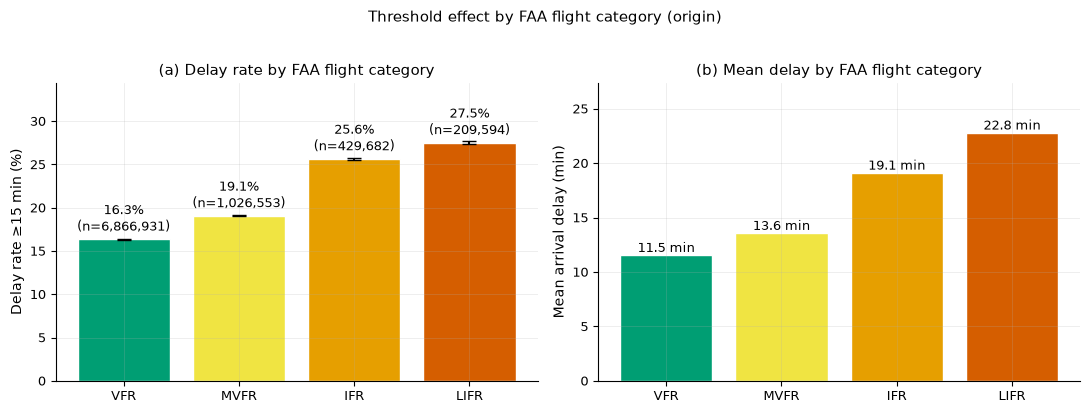


Threshold effect summary:
 cat       n  pct_delayed  mean_delay
 VFR 6866931    16.349909   11.534894
MVFR 1026553    19.056589   13.557788
 IFR  429682    25.635702   19.099604
LIFR  209594    27.502695   22.784178


In [9]:
cat_order = ['VFR', 'MVFR', 'IFR', 'LIFR']
cat_colors = [COLOR_GOOD, COLOR_MID, COLOR_BAD, COLOR_WORST]

ceiling_stats = []
for cat in cat_order:
    subset = df[df['org_ceiling_cat'] == cat]
    p, lo, hi = rate_ci(subset['ArrDel15'])
    ceiling_stats.append({
        'cat': cat,
        'n': len(subset),
        'pct_delayed': p * 100,
        'ci_lo': lo * 100,
        'ci_hi': hi * 100,
        'mean_delay': subset['ArrDelayMinutes'].mean(),
    })
stats_df = pd.DataFrame(ceiling_stats)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Panel A: Delay rate (%)
bars = axes[0].bar(stats_df['cat'], stats_df['pct_delayed'], color=cat_colors,
                    edgecolor='white', linewidth=1,
                    yerr=(stats_df['pct_delayed'] - stats_df['ci_lo'], stats_df['ci_hi'] - stats_df['pct_delayed']),
                    capsize=5)
for bar, row in zip(bars, stats_df.itertuples()):
    axes[0].text(bar.get_x() + bar.get_width()/2, row.pct_delayed + 1,
                 f'{row.pct_delayed:.1f}%\n(n={row.n:,})', ha='center', fontsize=9)
axes[0].set_ylabel('Delay rate ≥15 min (%)')
axes[0].set_title('(a) Delay rate by FAA flight category')
axes[0].set_ylim(0, max(stats_df['pct_delayed']) * 1.25)

# Panel B: Mean delay (min)
bars = axes[1].bar(stats_df['cat'], stats_df['mean_delay'], color=cat_colors,
                    edgecolor='white', linewidth=1)
for bar, row in zip(bars, stats_df.itertuples()):
    axes[1].text(bar.get_x() + bar.get_width()/2, row.mean_delay + 0.3,
                 f'{row.mean_delay:.1f} min', ha='center', fontsize=9)
axes[1].set_ylabel('Mean arrival delay (min)')
axes[1].set_title('(b) Mean delay by FAA flight category')
axes[1].set_ylim(0, max(stats_df['mean_delay']) * 1.2)

fig.suptitle('Threshold effect by FAA flight category (origin)', y=1.02, fontsize=11)
plt.tight_layout()
save_fig(fig, 'fig7_ceiling_threshold')
plt.show()

print()
print('Threshold effect summary:')
print(stats_df[['cat','n','pct_delayed','mean_delay']].to_string(index=False))